In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import Dataset

In [126]:
import requests
import io

url = "https://files.0xarchit.is-a.dev/datasets/equipment_anomaly_data.csv"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"}

response = requests.get(url, headers=headers)
df = pd.read_csv(io.StringIO(response.text))
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [127]:
df.head(10)

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0
5,49.510959,76.426729,4.809298,20.269692,Compressor,New York,1.0
6,66.903503,45.530759,1.548345,64.804922,Compressor,Houston,0.0
7,148.923369,22.214121,0.109819,39.944953,Turbine,San Francisco,1.0
8,50.403299,45.399899,2.231718,43.067667,Pump,Houston,0.0
9,63.886148,33.802912,1.139280,41.795515,Compressor,Atlanta,0.0


In [128]:
df.tail()

,temperature,pressure,vibration,humidity,equipment,location,faulty
7667,65.711521,37.505934,2.030521,49.331471,Pump,New York,0.0
7668,63.005855,45.164234,1.264585,61.905390,Pump,New York,0.0
7669,72.029230,34.757896,1.709046,49.972917,Pump,Atlanta,0.0
7670,107.086485,23.754114,1.142522,23.967977,Compressor,Atlanta,1.0
7671,28.468054,66.588978,4.677368,79.670225,Turbine,Chicago,1.0


In [129]:
df.shape

(7672, 7)

In [130]:
df.isnull().sum()

,0
temperature,0
pressure,0
vibration,0
humidity,0
equipment,0
location,0
faulty,0


In [131]:
df.describe()

,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   float64
dtypes: float64(5), object(2)
memory usage: 419.7+ KB


In [133]:
df['location'].unique()

array(['Atlanta', 'Chicago', 'San Francisco', 'New York', 'Houston'],
      dtype=object)

In [134]:
df['equipment'].unique()

array(['Turbine', 'Compressor', 'Pump'], dtype=object)

In [135]:
data = df.copy()

In [136]:
# custom encoder
data['location'] = data['location'].map({'Atlanta': 1, 'Chicago': 2, 'San Francisco': 3, 'New York': 4, 'Houston': 5})
data['equipment'] = data['equipment'].map({'Turbine': 1, 'Compressor': 2, 'Pump': 3})

data

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,1,1,0.0
1,75.740712,22.954018,2.338095,41.867407,2,2,0.0
2,71.358594,27.276830,1.389198,58.954409,1,3,0.0
3,71.616985,32.242921,1.770690,40.565138,3,1,0.0
4,66.506832,45.197471,0.345398,43.253795,3,4,0.0
...,...,...,...,...,...,...,...
7667,65.711521,37.505934,2.030521,49.331471,3,4,0.0
7668,63.005855,45.164234,1.264585,61.905390,3,4,0.0
7669,72.029230,34.757896,1.709046,49.972917,3,1,0.0
7670,107.086485,23.754114,1.142522,23.967977,2,1,1.0


In [137]:
# label encoder
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# data['location'] = le.fit_transform(data['location'])
# data['equipment'] = le.fit_transform(data['equipment'])
# data

In [138]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   int64  
 5   location     7672 non-null   int64  
 6   faulty       7672 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 419.7 KB


to avoid `bias and mode collapse` we use feature scaling

standard scaler  
min max scaler  
robust scaler

In [149]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
scaler1 = StandardScaler()
scaler2 = MinMaxScaler()
scaler3 = RobustScaler()

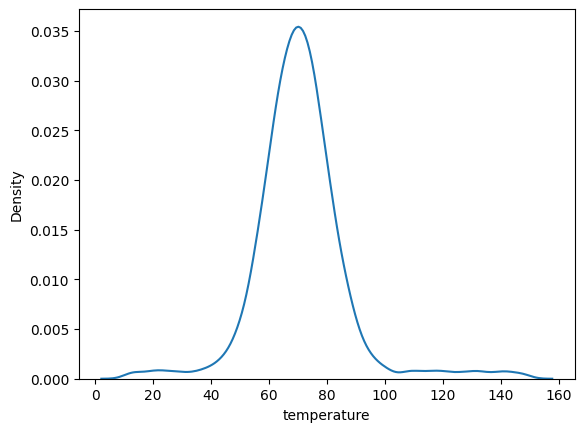

In [150]:
sns.kdeplot(data['temperature'])
plt.show()

In [152]:
dummy1 =scaler1.fit_transform(data[['temperature']])

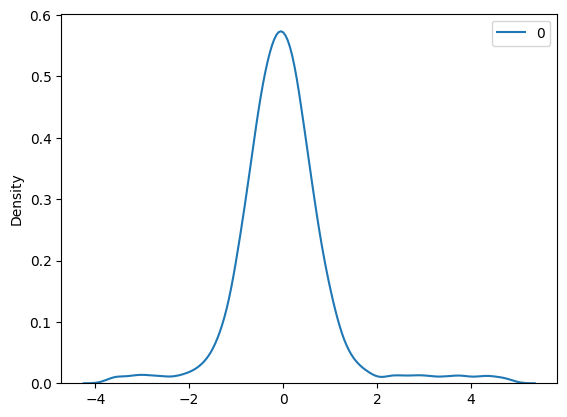

In [154]:
sns.kdeplot(dummy1)
plt.show()

In [ ]:
dummy2 = scaler2.fit_transform(data[['temperature']])

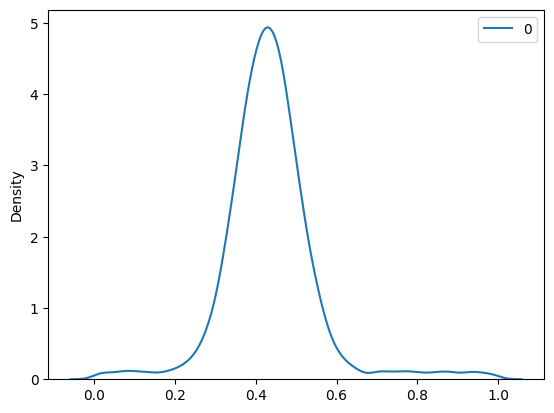

In [155]:
sns.kdeplot(dummy2)
plt.show()

In [156]:
dummy3 = scaler3.fit_transform(data[['temperature']])

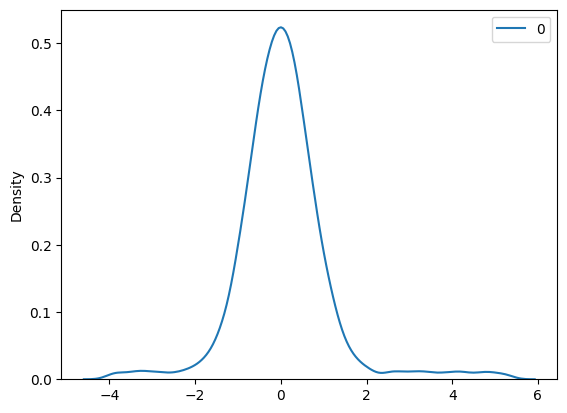

In [157]:
sns.kdeplot(dummy3)
plt.show()

EDA


In [139]:
data.corr()

,temperature,pressure,vibration,humidity,equipment,location,faulty
temperature,1.000000,0.049093,0.063448,0.000376,-0.000198,-0.010628,0.184296
pressure,0.049093,1.000000,0.077577,-0.014706,-0.008882,0.010456,0.202285
vibration,0.063448,0.077577,1.000000,0.025175,-0.000666,0.005824,0.431409
humidity,0.000376,-0.014706,0.025175,1.000000,0.017992,0.003358,0.012652
equipment,-0.000198,-0.008882,-0.000666,0.017992,1.000000,0.004918,-0.001546
location,-0.010628,0.010456,0.005824,0.003358,0.004918,1.000000,0.003940
faulty,0.184296,0.202285,0.431409,0.012652,-0.001546,0.003940,1.000000


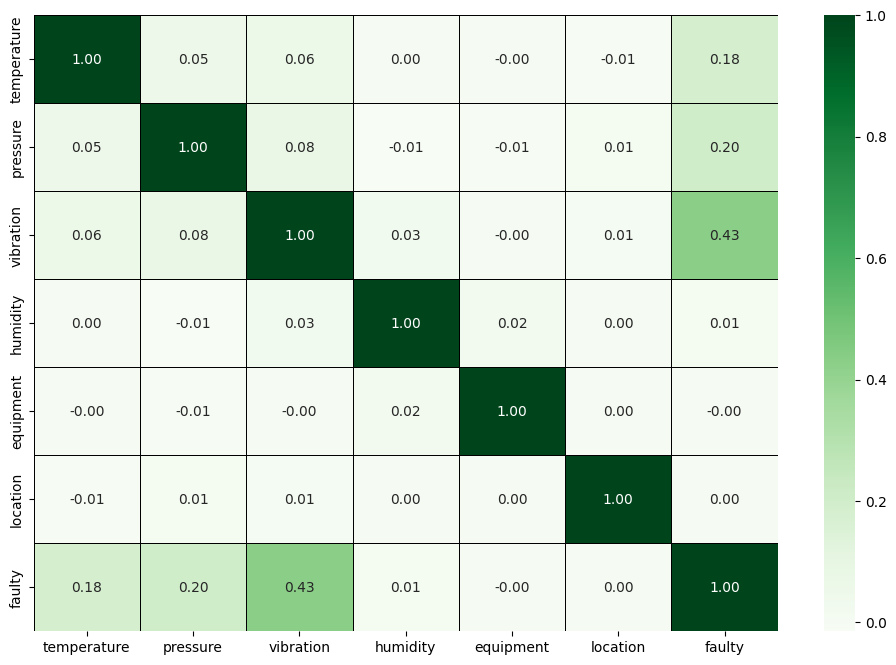

In [140]:
plt.figure(figsize=(12, 8))
fig = sns.heatmap(data.corr(), cmap='Greens', annot=True, linecolor="black", linewidths=0.5, fmt='.2f')

EDA

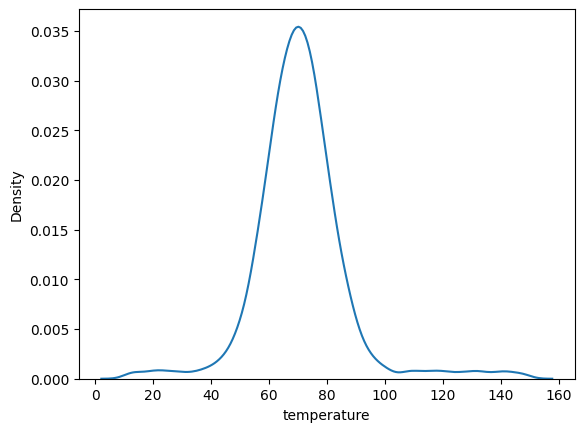

In [147]:
sns.kdeplot(data['temperature'])
plt.show()

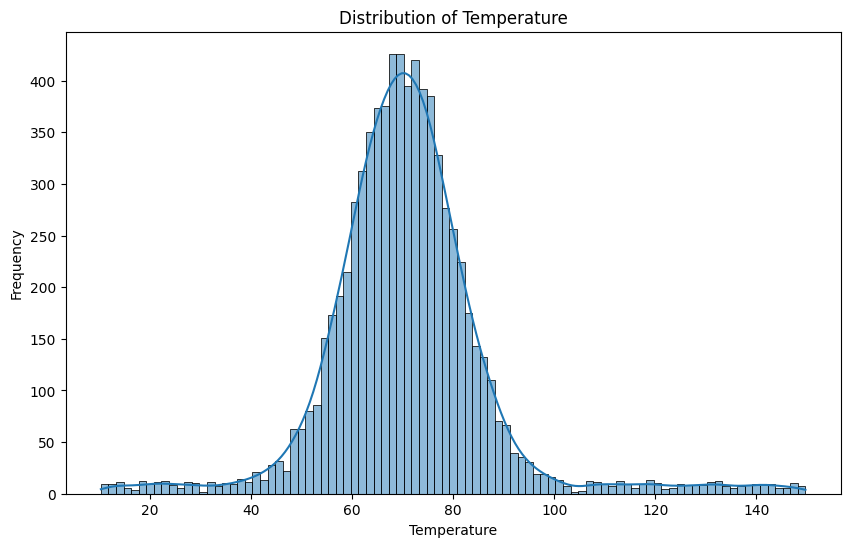

In [141]:
plt.figure(figsize=(10, 6))
sns.histplot(data['temperature'], kde=True)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

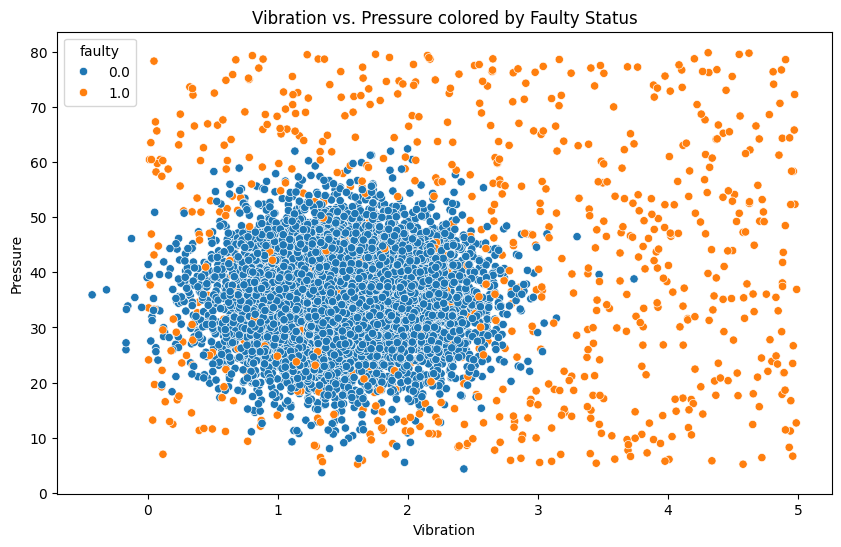

In [142]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='vibration', y='pressure', hue='faulty', data=data)
plt.title('Vibration vs. Pressure colored by Faulty Status')
plt.xlabel('Vibration')
plt.ylabel('Pressure')
plt.show()

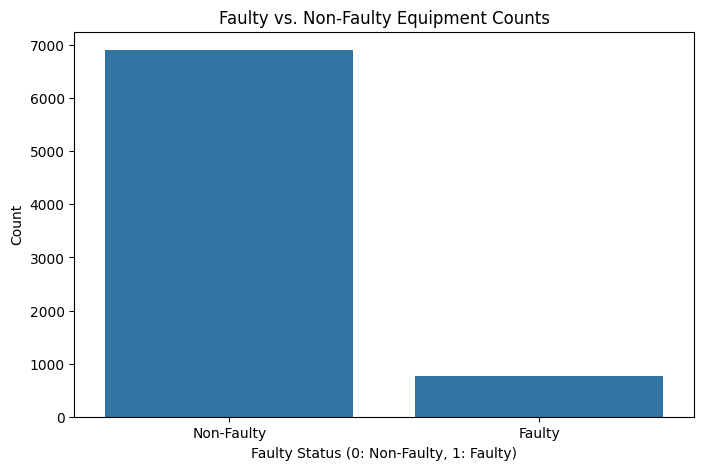

In [143]:
plt.figure(figsize=(8, 5))
sns.countplot(x='faulty', data=data)
plt.title('Faulty vs. Non-Faulty Equipment Counts')
plt.xlabel('Faulty Status (0: Non-Faulty, 1: Faulty)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Faulty', 'Faulty'])
plt.show()

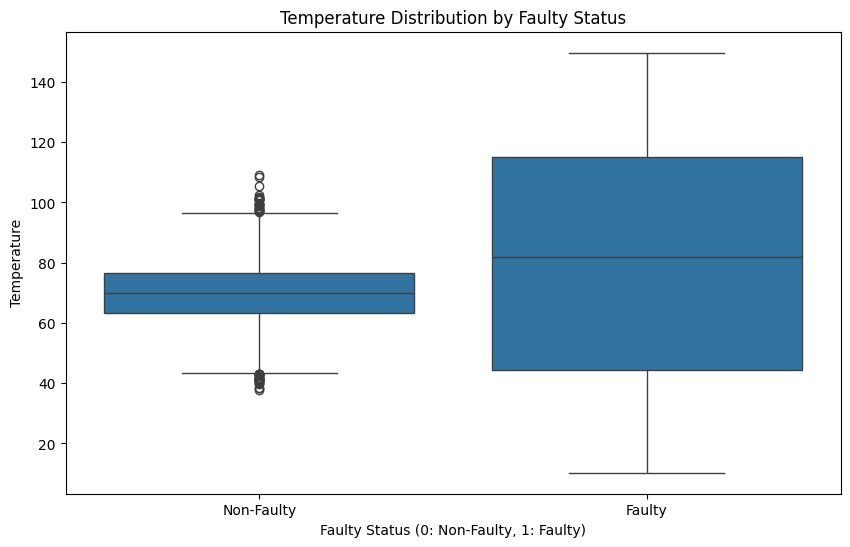

In [144]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='faulty', y='temperature', data=data)
plt.title('Temperature Distribution by Faulty Status')
plt.xlabel('Faulty Status (0: Non-Faulty, 1: Faulty)')
plt.ylabel('Temperature')
plt.xticks([0, 1], ['Non-Faulty', 'Faulty'])
plt.show()

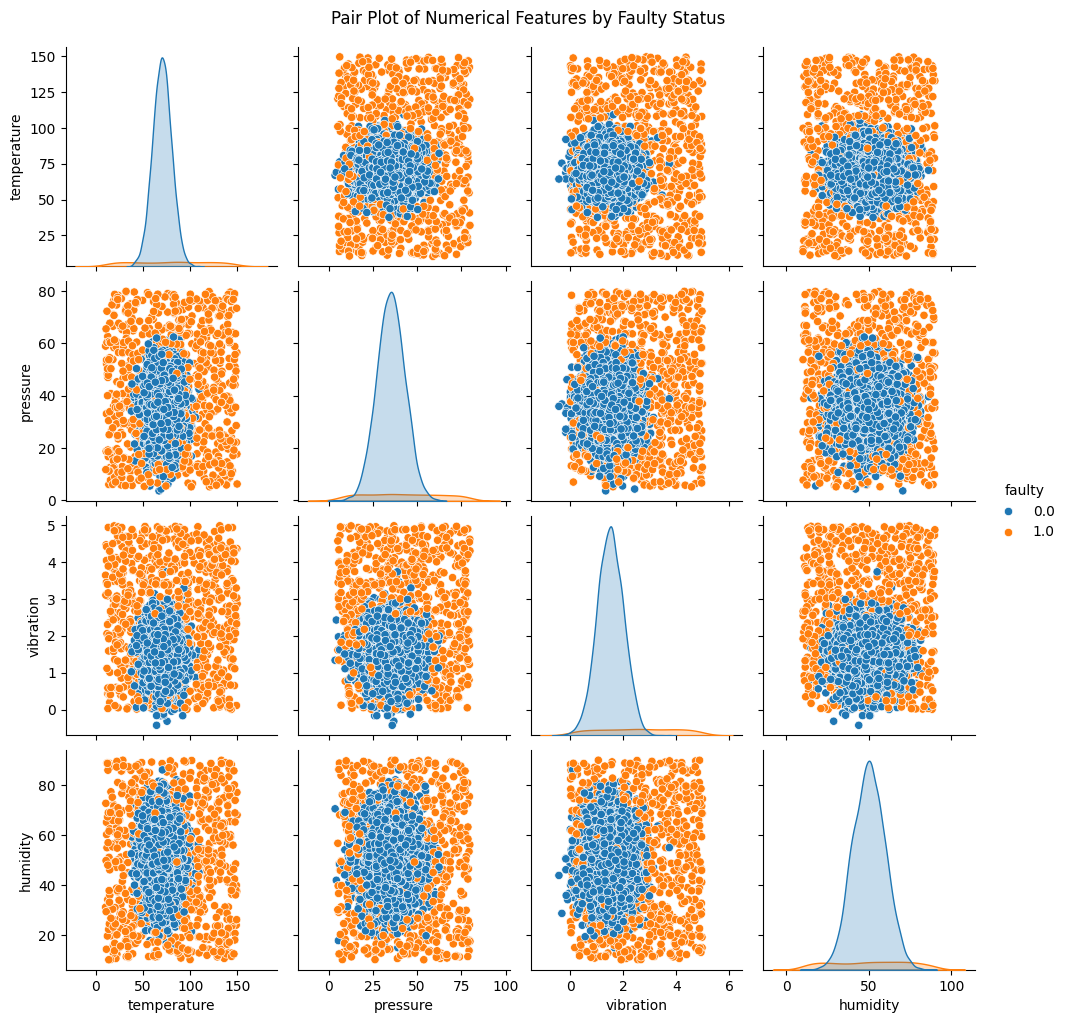

In [145]:
sns.pairplot(data, vars=['temperature', 'pressure', 'vibration', 'humidity'], hue='faulty')
plt.suptitle('Pair Plot of Numerical Features by Faulty Status', y=1.02)
plt.show()

In [158]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [161]:
X = data.drop('faulty', axis=1)
Y = data['faulty']

In [162]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=42)